# Summary

1. The original data was in a tsv format
    * 3 meaningful columns: "From Verse", "To Verse", "Votes"
    * 344,756 rows
2. The votes range from a minimum of -86 to a maximum of 1,291. The data is not zero-inflated; 98.98% of the values are positive, with the most common vote counts falling between 1 and 10
3. Negative Votes: There are 1,243 rows with negative votes. Qualitative review shows no apparent connection between these verses, suggesting they are false positives generated by the original algorithm
4. Zero Votes: There are 2,271 rows with a vote of 0. These verses often share semantic connections but lack a pragmatic connection.
5. Positive Votes & Magnitude: While extreme positive votes (e.g., 1,000+) show unmistakable thematic links, there is no consistent relationship between the magnitude of the votes and the qualitative strength of the connection across tiers. Links with 4 or 6 votes present connections that are just as reasonable as those with over 700 votes.
    * However, links with only 1 vote are closer aligned with links with 0 votes, displaying semantic connections but no pragmatic connections. This suggests that the votes are related to the reliability: the lower positive votes have a higher likelihood of errors. This hypothesis is not yet tested.

Next Steps:
1. Some of these passages used as a single node are extremely long (e.g. Matthew 26:1-27). Need to examine.
2. Examine links with votes in range of 1-5 more closely, test hypothesis.
    * Based on the results, it will probably be good to remove votes under a certain threshold
3. It might be good to remove all links between nodes of the same chapter -> is it truly a noteworthy reference if it's in the same page?
4. Remove zero/negative vote links.

# Work

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

In [126]:
# import the data
raw_data = pd.read_csv('cross_references.tsv', sep='\t')
raw_data.head(5)

,From Verse,To Verse,Votes,#www.openbible.info CC-BY 2026-09-07
0,Gen.1.1,Exod.20.11,154,NaN
1,Gen.1.1,Jer.51.15,89,NaN
2,Gen.1.1,Heb.1.10,190,NaN
3,Gen.1.1,Ps.121.2,65,NaN
4,Gen.1.1,Ps.115.15,82,NaN


In [127]:
df = raw_data.drop(columns=['#www.openbible.info CC-BY 2026-09-07'])
df.sample(n=5, random_state=42)

,From Verse,To Verse,Votes
338934,Rev.2.15,Rev.2.6,6
62639,2Sam.3.8,Ps.2.1-Ps.2.4,2
138866,Ps.145.1,Ps.45.1,5
111500,Ps.16.7,Luke.6.12,7
98057,Neh.13.22,2Tim.4.7-2Tim.4.8,1


In [128]:
print(f"shape of the dataframe: {df.shape}")

shape of the dataframe: (344756, 3)


In [129]:
print("Data types of each columns:")
display(df.dtypes)

Data types of each columns:


From Verse    object
To Verse      object
Votes          int64
dtype: object

## Looking into "Votes" column
I'm not quite sure what it represents.
A few initial hypothesis:

1. Strength of the connection, as calculated by an algorithm
2. Votes by a community on the validity of the connection

Whichever it is, my initial thought is that it has a similar purpose as weights of each edges.

In [130]:
votes = df['Votes']

In [131]:
votes.describe()

count    344756.000000
mean          6.437454
std          16.058007
min         -86.000000
25%           2.000000
50%           3.000000
75%           6.000000
max        1291.000000
Name: Votes, dtype: float64

### Distribution of Votes

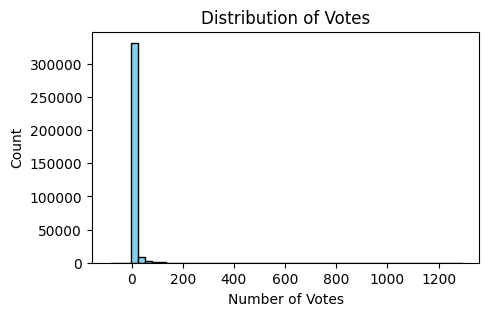

In [132]:
plt.figure(figsize=(5, 3), dpi=100)
plt.hist(votes, bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Votes')
plt.xlabel('Number of Votes')
plt.ylabel('Count')

plt.show()

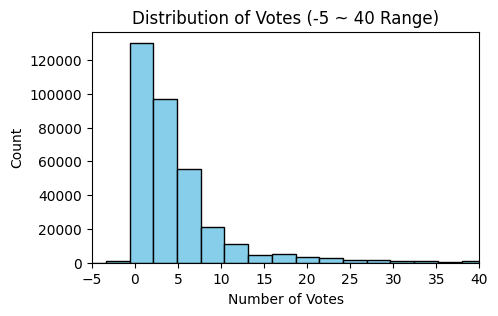

In [133]:
# limit x
plt.figure(figsize=(5, 3), dpi=100)
plt.hist(votes, bins=500, color='skyblue', edgecolor='black')
plt.xlim(-5, 40)

plt.title('Distribution of Votes (-5 ~ 40 Range)')
plt.xlabel('Number of Votes')
plt.ylabel('Count')

plt.show()

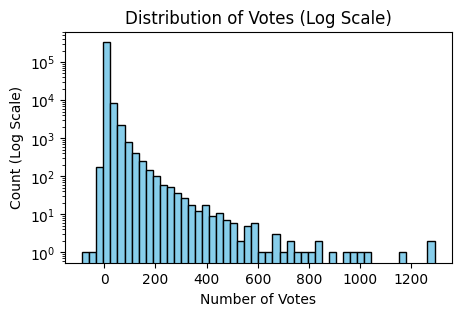

In [134]:
# log scale
plt.figure(figsize=(5, 3), dpi=100)
plt.hist(votes, bins=50, color='skyblue', edgecolor='black')
plt.yscale('log')

plt.title('Distribution of Votes (Log Scale)')
plt.xlabel('Number of Votes')
plt.ylabel('Count (Log Scale)')

plt.show()

In [135]:
# Percent positive, negative, and 0 (since it seems 0 skewed)
print(f"Negative: {(votes < 0).mean() * 100:.2f}%")
print(f"Zero: {(votes == 0).mean() * 100:.2f}%")
print(f"Positive: {(votes > 0).mean() * 100:.2f}%")

Negative: 0.36%
Zero: 0.66%
Positive: 98.98%


In [136]:
print(f"10 most common votes: {votes.value_counts().head(10)}")

10 most common votes: Votes
2     114750
3      60071
4      36915
5      25990
6      17313
1      13239
7      12329
8       9161
9       6981
10      5291
Name: count, dtype: int64


Votes isn't zero-inflated. Most values lie between 0-10.

The negative values and extreme values (e.g. 1290) raise questions.

### Investigate Extreme Values

#### Negative Values/Zeros

In [137]:
# identify links with negative votes
negative_votes = df.loc[df['Votes'] < 0].sort_values(by='Votes', ascending=True)
print(f"There are {negative_votes.shape[0]} rows with negative votes")

There are 1243 rows with negative votes


In [138]:
negative_votes.head(5)

,From Verse,To Verse,Votes
311480,Eph.6.17,1Sam.17.58,-86
28,Gen.1.1,Exod.31.18,-38
132798,Ps.110.1,Luke.22.41,-27
68,Gen.1.2,Nah.2.10,-26
332319,1Pet.1.16,Amos.3.3,-20


In [139]:
negative_votes.tail(5)

,From Verse,To Verse,Votes
269904,John.12.15,Judg.5.10,-1
269905,John.12.15,Deut.17.16,-1
269907,John.12.15,1Kgs.1.33,-1
269025,John.10.34,Exod.22.28,-1
255780,Luke.10.1,Luke.7.13,-1


Most negative votes (-86):
* Ephesians 6:17 "Take the helmet of salvation and the sword of the Spirit, which is the word of God."
* 1 Samuel 17:58 "'Whose son are you, young man?' Saul asked him. David said, 'I am the son of your servant Jesse of Bethlehem.'"

Least negative votes (-1):
* Luke 10:1 "After this the Lord appointed seventy-two others and sent them two by two ahead of him to every town and place where he was about to go."
* Luke 7:13 "When the Lord saw her, his heart went out to her and he said, 'Don't cry.'"

**There are no apparent connections between the verses with negative votes. This could signify that negative votes in general are false positives from the original algorithm (i.e. no actual link).**

### Zeros

In [140]:
# identify links with votes of 0
zero_votes = df.loc[df['Votes'] == 0]
print(f"There are {zero_votes.shape[0]} rows with votes of 0")

There are 2271 rows with votes of 0


In [141]:
zero_votes.head(5)

,From Verse,To Verse,Votes
141,Gen.1.7,Gen.1.15,0
148,Gen.1.8,Gen.1.5,0
166,Gen.1.10,Ps.104.31,0
253,Gen.1.17,Acts.13.47,0
273,Gen.1.21,Matt.12.40,0


Example 1:
* Genesis 1:7 "So God made the vault and separated the water under the vault from the water above it. And it was so."
* Genesis 1:15 "and let them be lights in the vault of the sky to give light on the earth."

Example 2:
* Genesis 1:17 "God set them in the vault of the sky to give light on the earth,"
* Acts 13:47 "For this is what the Lord has commanded us: 'I have made you a light for the Gentiles, that you may bring salvation to the ends of the earth.'"

Example 3:
* Genesis 1:21 "So God created the great creatures of the sea and every living thing with which the water teems and that moves about in it, according to their kinds, and every winged bird according to its kind. And God saw that it was good."
* Matthew 12:40 "For as Jonah was three days and three nights in the belly of a huge fish, so the Son of Man will be three days and three nights in the heart of the earth."

**There is a much stronger semantic connection between the verses here ('vault', 'light', 'sea/fish'). However, there is a lack of pragmatic connection here.**

#### Extreme Positives vs Low Positives
Compare if magnitude of votes matters

In [142]:
positive_votes = df.loc[df['Votes'] > 0].sort_values(by='Votes', ascending=False)
print(f"There are {positive_votes.shape[0]} positive rows")

There are 341242 positive rows


In [143]:
positive_votes.head(5)

,From Verse,To Verse,Votes
184176,Jer.29.11,Isa.55.8-Isa.55.12,1291
292061,Rom.8.29,Eph.1.4-Eph.1.5,1280
292089,Rom.8.29,Jer.1.5,1154
313729,Phil.4.13,Isa.41.10,1030
167022,Isa.44.3,Joel.2.28,1001


In [144]:
positive_votes.tail(5)

,From Verse,To Verse,Votes
5576,Gen.22.9,1Pet.2.24,1
5574,Gen.22.9,Gen.12.7,1
5573,Gen.22.9,Gen.8.20,1
5572,Gen.22.9,Matt.26.1-Matt.26.27,1
249304,Mark.14.12,Matt.3.15,1


**Extreme positive votes:**
* Romans 8:29 "For those God foreknew he also predestined to be conformed to the image of his Son, that he might be the firstborn among many brothers and sisters."
* Ephesians 1:4-5 "For he chose us in him before the creation of the world to be holy and blameless in his sight. In love he predestined us for adoption to sonship through Jesus Christ, in accordance with his pleasure and will—"

* Jeremiah 1:5 "'Before I formed you in the womb I knew you, before you were born I set you apart; I appointed you as a prophet to the nations.'"

**Low positive votes:**

Connection 1:
* Genesis 22:9 "When they reached the place God had told him about, Abraham built an altar there and arranged the wood on it. He bound his son Isaac and laid him on the altar, on top of the wood."
* 1 Peter 2:24 "'He himself bore our sins' in his body on the cross, so that we might die to sins and live for righteousness; 'by his wounds you have been healed'"

Connection 2: 
* Mark 14:12 "On the first day of the Festival of Unleavened Bread, when it was customary to sacrifice the Passover lamb, Jesus' disciples asked him, 'Where do you want us to go and make preparations for you to eat the Passover?'"
* Matthew 3:15 "Jesus replied, 'Let it be so now; it is proper for us to do this to fulfill all righteousness.' Then John consented."

**The extreme positive votes unmistakenly share themes between the verses. However, the connection is questionable for links of low positive votes.**

* There may be a relation between magnitude and the strength of the connection
* Another possibility is that there is a threshold at a low positive number: any votes above that threshold could indicate a connection, any below could be false positives.

### Qualitatively test the idea of magnitude $\propto$ weight

In [153]:
# bin the votes
bins = [0, 100, 250, 500, 750, float('inf')]
group_names = ['1-100', '101-250', '251-500', '501-750', '751-']

positive_votes['vote_group'] = pd.cut(positive_votes['Votes'], bins=bins, labels=group_names)
positive_votes

,From Verse,To Verse,Votes,vote_group
184176,Jer.29.11,Isa.55.8-Isa.55.12,1291,751-
292061,Rom.8.29,Eph.1.4-Eph.1.5,1280,751-
292089,Rom.8.29,Jer.1.5,1154,751-
313729,Phil.4.13,Isa.41.10,1030,751-
167022,Isa.44.3,Joel.2.28,1001,751-
...,...,...,...,...
5576,Gen.22.9,1Pet.2.24,1,1-100
5574,Gen.22.9,Gen.12.7,1,1-100
5573,Gen.22.9,Gen.8.20,1,1-100
5572,Gen.22.9,Matt.26.1-Matt.26.27,1,1-100


In [154]:
for group in group_names:
    print(f"Group: {group}")
    display(positive_votes.loc[positive_votes['vote_group']==group].sample(2, random_state=42))

Group: 1-100


,From Verse,To Verse,Votes,vote_group
279206,Acts.9.17,Acts.6.6,6,1-100
183366,Jer.26.2,Acts.5.42,4,1-100


Group: 101-250


,From Verse,To Verse,Votes,vote_group
226025,Zech.4.6,2Cor.10.4-2Cor.10.5,163,101-250
256004,Luke.10.19,Rev.11.5,103,101-250


Group: 251-500


,From Verse,To Verse,Votes,vote_group
51236,Josh.23.10,Deut.3.22,439,251-500
184169,Jer.29.11,Isa.46.10-Isa.46.11,383,251-500


Group: 501-750


,From Verse,To Verse,Votes,vote_group
167007,Isa.44.3,Isa.59.21,597,501-750
313735,Phil.4.13,Isa.40.29-Isa.40.31,563,501-750


Group: 751-


,From Verse,To Verse,Votes,vote_group
165726,Isa.41.10,Josh.1.9,775,751-
141079,Prov.4.23,Luke.6.45,834,751-


#### 1-100
1: Votes = 6
* Acts 9:17 "Then Ananias went to the house and entered it. Placing his hands on Saul, he said, 'Brother Saul, the Lord—Jesus, who appeared to you on the road as you were coming here—has sent me so that you may see again and be filled with the Holy Spirit.'"
* Acts 6:6 "They presented these men to the apostles, who prayed and laid their hands on them."

2: Votes = 4
* Jeremiah 26:2 "This is what the Lord says: Stand in the courtyard of the Lord’s house and speak to all the people of the towns of Judah who come to worship in the house of the Lord. Tell them everything I command you; do not omit a word."
* Acts 5:42 "Day after day, in the temple courts and from house to house, they never stopped teaching and proclaiming the good news that Jesus is the Messiah."

#### 101-250
1: Votes = 163
* Zechariah 4:6 "So he said to me, “This is the word of the Lord to Zerubbabel: ‘Not by might nor by power, but by my Spirit,’ says the Lord Almighty."
* 2 Corinthians 10:4-5 "The weapons we fight with are not the weapons of the world. On the contrary, they have divine power to demolish strongholds. We demolish arguments and every pretension that sets itself up against the knowledge of God, and we take captive every thought to make it obedient to Christ."

2: Votes = 103
* Luke 10:19 "I have given you authority to trample on snakes and scorpions and to overcome all the power of the enemy; nothing will harm you."
* Revelations 11:5 "If anyone tries to harm them, fire comes from their mouths and devours their enemies. This is how anyone who wants to harm them must die."

#### 251-500
1: Votes = 439
* Joshua 23:10 "One of you routs a thousand, because the Lord your God fights for you, just as he promised."
* Deuteronomy 3:22 "Do not be afraid of them; the Lord your God himself will fight for you."

2: Votes = 383
* Jeremiah 29:11 "For I know the plans I have for you,” declares the Lord, “plans to prosper you and not to harm you, plans to give you hope and a future."
* Isaiah 46:10-11 "I make known the end from the beginning, from ancient times, what is still to come. I say, ‘My purpose will stand, and I will do all that I please.’ From the east I summon a bird of prey; from a far-off land, a man to fulfill my purpose. What I have said, that I will bring about; what I have planned, that I will do."

#### 501-750
1: Votes = 597
* Isaiah 44:3 "For I will pour water on the thirsty land, and streams on the dry ground; I will pour out my Spirit on your offspring, and my blessing on your descendants."
* Isaiah 59:21 "“As for me, this is my covenant with them,” says the Lord. “My Spirit, who is on you, will not depart from you, and my words that I have put in your mouth will always be on your lips, on the lips of your children and on the lips of their descendants—from this time on and forever,” says the Lord."

2: Votes = 563
* Philippians 4:13 "I can do all this through him who gives me strength."
* Isaiah 40:29-31 "He gives strength to the weary and increases the power of the weak. Even youths grow tired and weary, and young men stumble and fall; but those who hope in the Lord will renew their strength. They will soar on wings like eagles; they will run and not grow weary, they will walk and not be faint."

#### 751-
1: Votes = 775
* Isaiah 40:10 "See, the Sovereign Lord comes with power, and he rules with a mighty arm. See, his reward is with him, and his recompense accompanies him."
* Joshua 1:9 "Have I not commanded you? Be strong and courageous. Do not be afraid; do not be discouraged, for the Lord your God will be with you wherever you go.”"

2: Votes = 834
* Proverbs 4:23 "Above all else, guard your heart, for everything you do flows from it."
* Luke 6:45 "A good man brings good things out of the good stored up in his heart, and an evil man brings evil things out of the evil stored up in his heart. For the mouth speaks what the heart is full of."

**There are no apparent relationship between the magnitude of the votes and the qualitative connection between the verses.** The links in the first group (votes of 6 and 4) were both reasonable connections, and were not significantly weaker than those of the last group (votes of 775 and 834).